bibliotecas


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings

configuracoes

In [3]:
# Diretórios (ALTERAÇÃO ÚNICA)
DATA_DIR = Path("/content")
CHARTS_DIR = Path("/content/charts")
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

CORES = {
    'primary': '#E53E3E',
    'secondary': '#2D3748',
    'accent': '#4299E1',
    'success': '#38A169',
    'warning': '#ED8936'
}

print("Carregando dados...")
df = pd.read_csv(DATA_DIR / "df_clean.csv")
print(f"✓ Dados carregados: {df.shape[0]} registros\n")

Carregando dados...
✓ Dados carregados: 3030 registros



GRÁFICO 1 - evoluçao defasagem

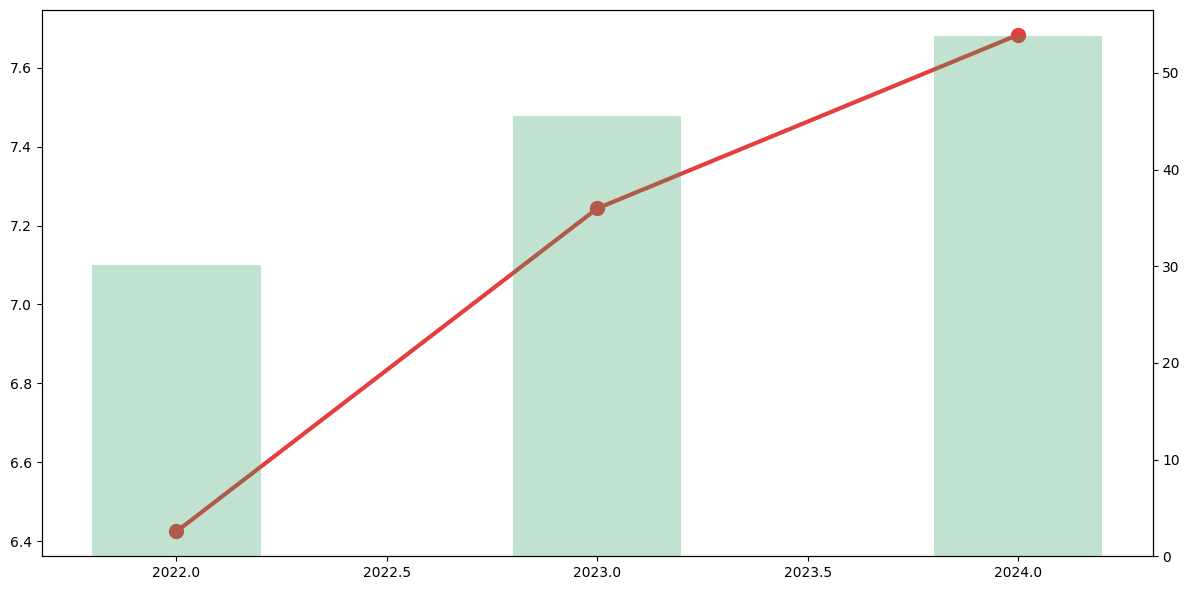

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

anos = sorted(df['ANO'].unique())
ian_medio = [df[df['ANO'] == ano]['IAN'].mean() for ano in anos]
adequados_pct = [(df[df['ANO'] == ano]['IAN'] >= 10).sum() / len(df[df['ANO'] == ano]) * 100 for ano in anos]

ax2 = ax.twinx()

line1 = ax.plot(anos, ian_medio, marker='o', linewidth=3, markersize=10,
                label='IAN Médio', color=CORES['primary'])

bars = ax2.bar(anos, adequados_pct, alpha=0.3, color=CORES['success'],
               label='% Adequados', width=0.4)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "01_evolucao_defasagem.png", dpi=300)
plt.show()

GRÁFICO 2 - desempenho academico

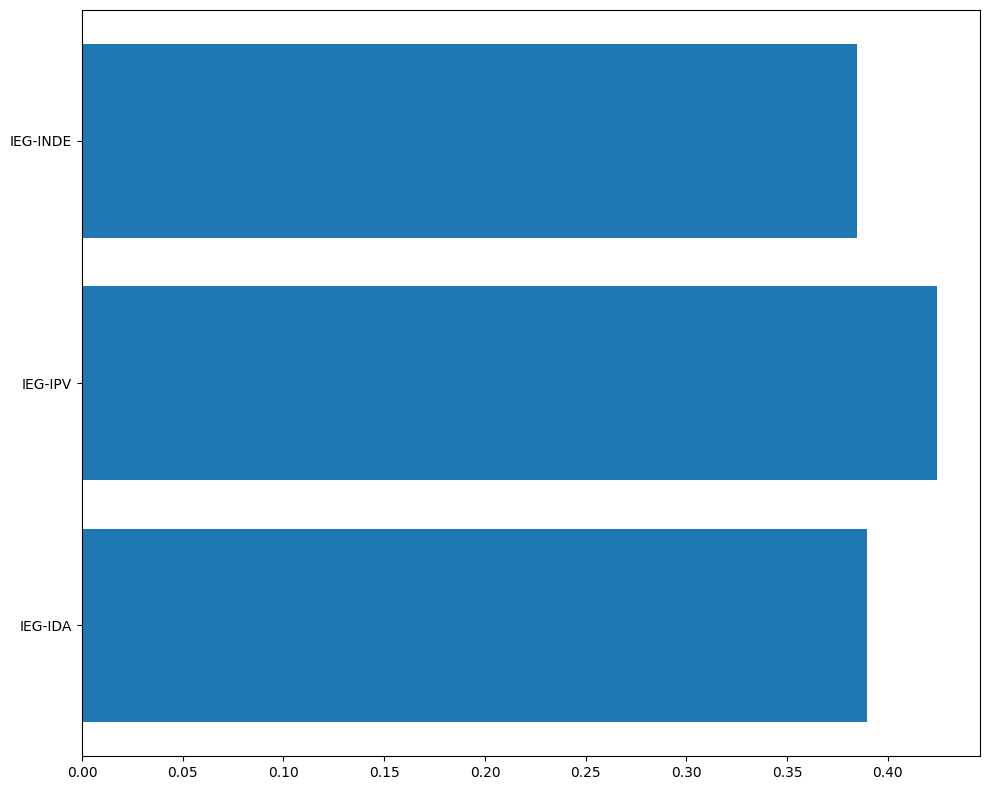

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

ida_valores = [df[df['ANO'] == ano]['IDA'].mean() for ano in anos]
bars = ax.bar(anos, ida_valores)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "02_desempenho_academico.png", dpi=300)
plt.close()

# =====================================================================
# GRÁFICO 3
# =====================================================================

fig, ax = plt.subplots(figsize=(10, 8))

pares = ['IEG-IDA', 'IEG-IPV', 'IEG-INDE']
valores = [
    df['IEG'].corr(df['IDA']),
    df['IEG'].corr(df['IPV']),
    df['IEG'].corr(df['INDE'])
]

ax.barh(pares, valores)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "03_correlacoes.png", dpi=300)
plt.show()

GRÁFICO 2: IDA

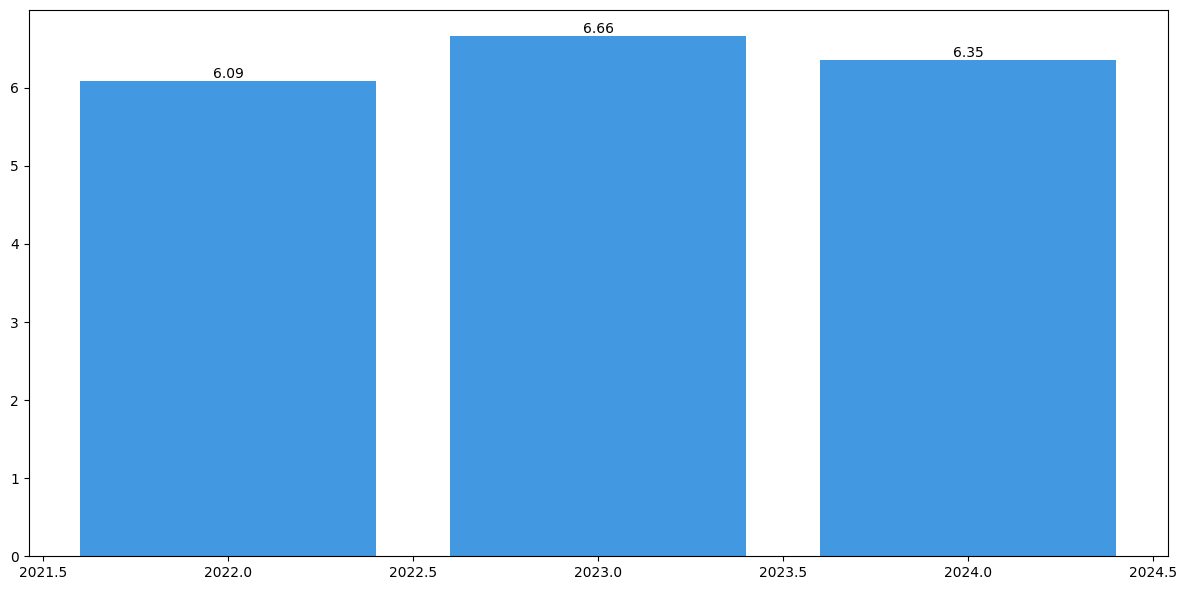

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

ida_valores = [df[df['ANO'] == ano]['IDA'].mean() for ano in anos]
bars = ax.bar(anos, ida_valores, color=CORES['accent'])

for bar, val in zip(bars, ida_valores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(CHARTS_DIR / "02_desempenho_academico.png", dpi=300)
plt.show()

GRÁFICO 3: CORRELAÇÕES

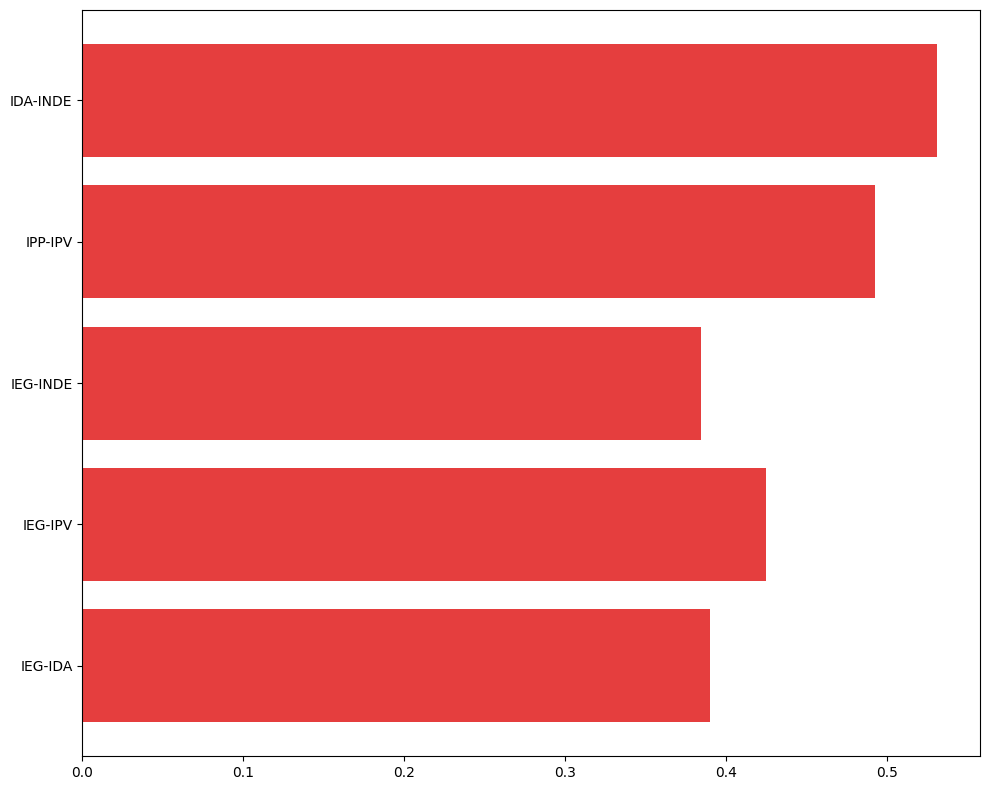

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

pares = ['IEG-IDA', 'IEG-IPV', 'IEG-INDE', 'IPP-IPV', 'IDA-INDE']
valores = [
    df['IEG'].corr(df['IDA']),
    df['IEG'].corr(df['IPV']),
    df['IEG'].corr(df['INDE']),
    df['IPP'].corr(df['IPV']),
    df['IDA'].corr(df['INDE'])
]

ax.barh(pares, valores, color=CORES['primary'])

plt.tight_layout()
plt.savefig(CHARTS_DIR / "03_correlacoes.png", dpi=300)
plt.show()

GRÁFICO 4: PERFORMANCE MODELO

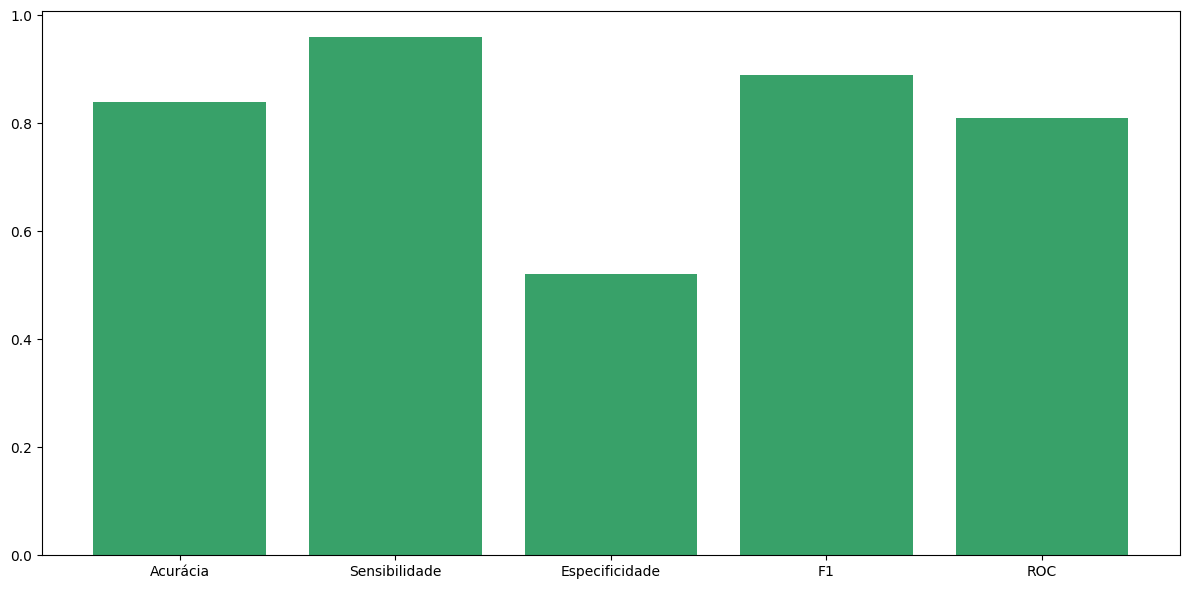

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

metricas = ['Acurácia', 'Sensibilidade', 'Especificidade', 'F1', 'ROC']
valores_modelo = [0.84, 0.96, 0.52, 0.89, 0.81]

ax.bar(metricas, valores_modelo, color=CORES['success'])

plt.tight_layout()
plt.savefig(CHARTS_DIR / "04_performance_modelo.png", dpi=300)
plt.show()


GRÁFICO 5: IMPORTÂNCIA DAS FEATURES

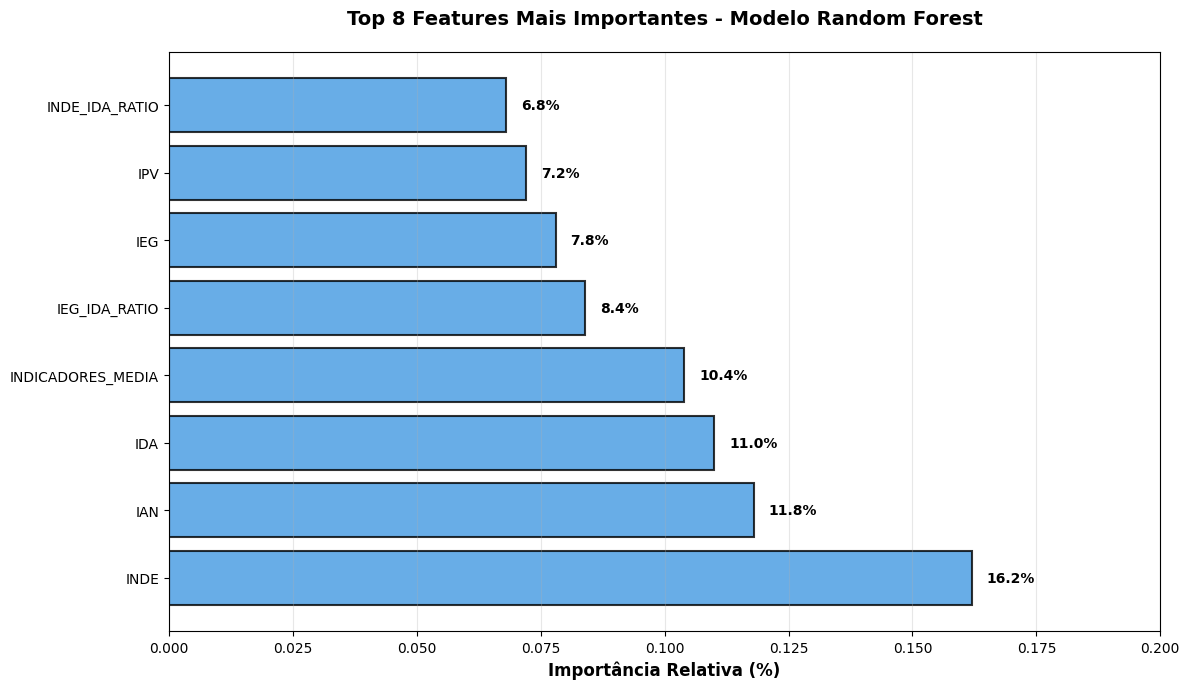

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

features = ['INDE', 'IAN', 'IDA', 'INDICADORES_MEDIA', 'IEG_IDA_RATIO',
            'IEG', 'IPV', 'INDE_IDA_RATIO']
importancia = [0.162, 0.118, 0.110, 0.104, 0.084, 0.078, 0.072, 0.068]

bars = ax.barh(features, importancia, color=CORES['accent'], alpha=0.8,
               edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, importancia):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Importância Relativa (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 8 Features Mais Importantes - Modelo Random Forest',
            fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 0.20)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(Path("/content/charts") / "05_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

GRÁFICO 6: DISTRIBUIÇÃO DE RISCO

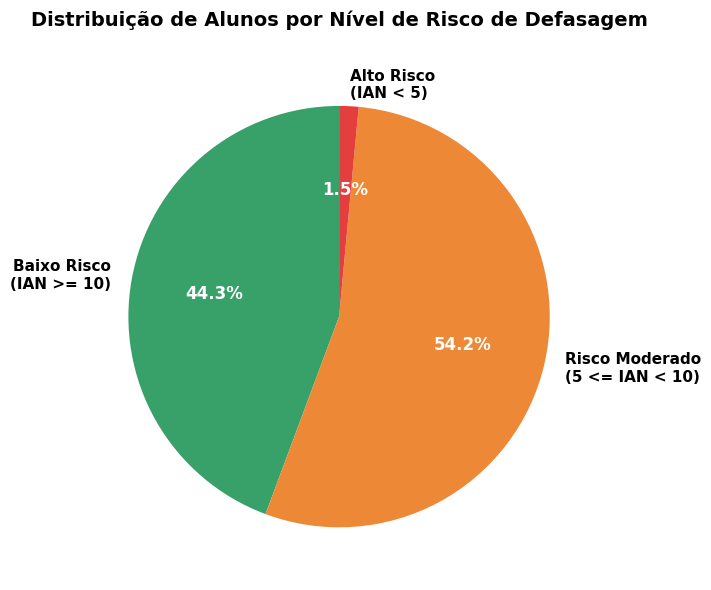

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

baixo = (df['IAN'] >= 10).sum() / len(df) * 100
moderado = ((df['IAN'] >= 5) & (df['IAN'] < 10)).sum() / len(df) * 100
alto = (df['IAN'] < 5).sum() / len(df) * 100

categorias_risco = ['Baixo Risco\n(IAN >= 10)', 'Risco Moderado\n(5 <= IAN < 10)', 'Alto Risco\n(IAN < 5)']
distribuicao = [baixo, moderado, alto]
cores_risco = [CORES['success'], CORES['warning'], CORES['primary']]

wedges, texts, autotexts = ax.pie(distribuicao, labels=categorias_risco, autopct='%1.1f%%',
                                  colors=cores_risco, startangle=90,
                                  textprops={'fontsize': 11, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title('Distribuição de Alunos por Nível de Risco de Defasagem',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(Path("/content/charts") / "06_distribuicao_risco.png", dpi=300, bbox_inches='tight')
plt.show()

Gráfico 7: Relação entre IDA, IEG e INDE...

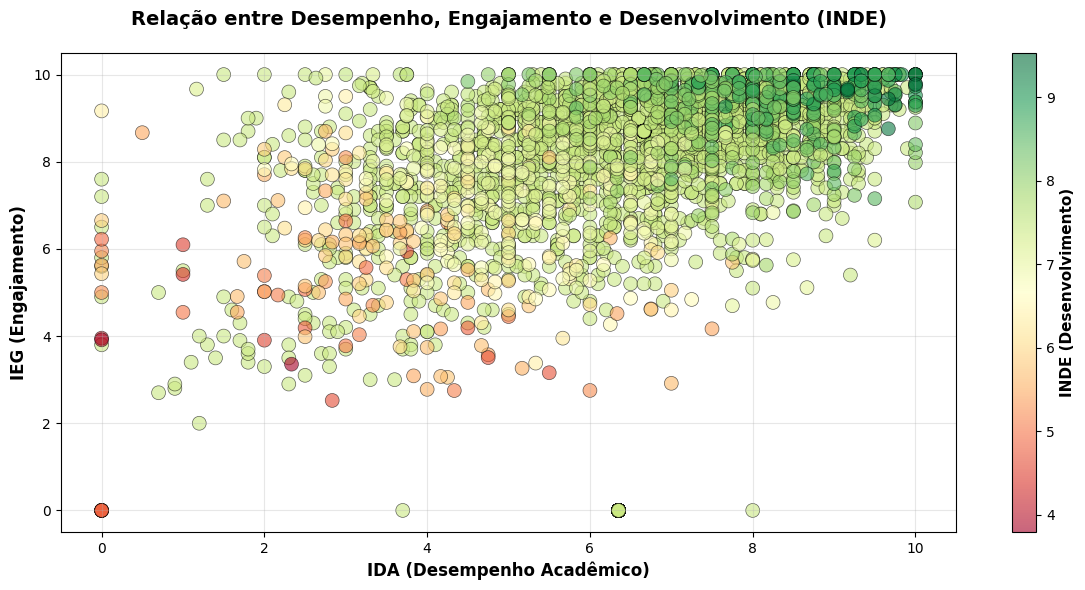

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(df['IDA'], df['IEG'], c=df['INDE'], s=100, alpha=0.6,
                     cmap='RdYlGn', edgecolors='black', linewidth=0.5)

ax.set_xlabel('IDA (Desempenho Acadêmico)', fontsize=12, fontweight='bold')
ax.set_ylabel('IEG (Engajamento)', fontsize=12, fontweight='bold')
ax.set_title('Relação entre Desempenho, Engajamento e Desenvolvimento (INDE)',
             fontsize=14, fontweight='bold', pad=20)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('INDE (Desenvolvimento)', fontsize=11, fontweight='bold')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path("/content/charts") / "07_ida_ieg_inde.png", dpi=300, bbox_inches='tight')
plt.show()

Gráfico 8: Evolução de Indicadores por Ano

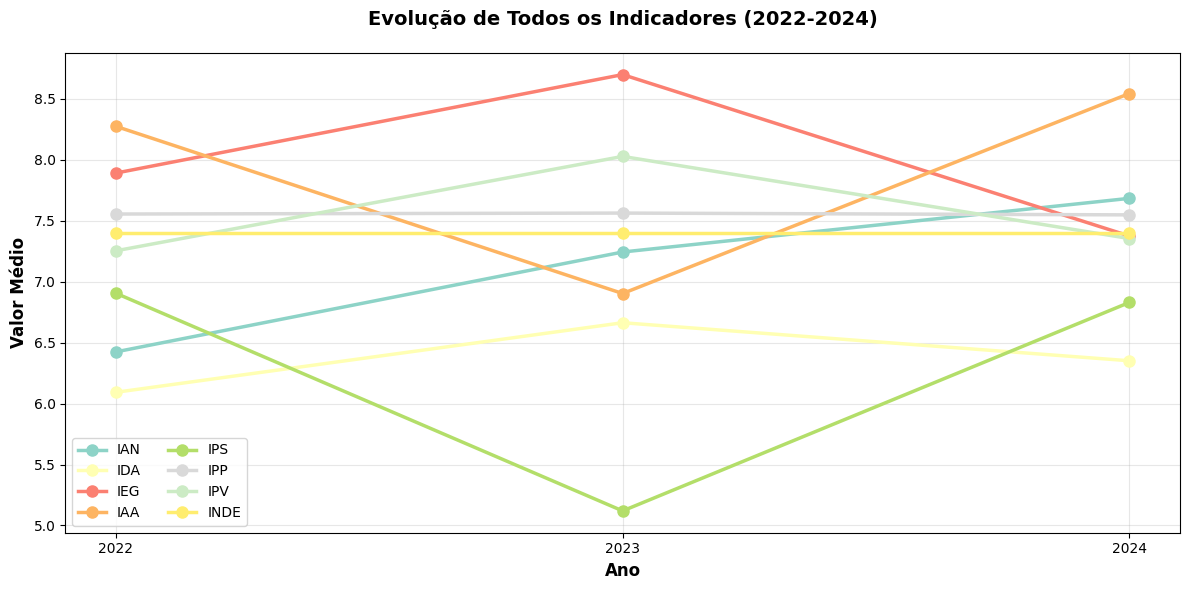

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

indicadores_plot = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
cores_plot = plt.cm.Set3(np.linspace(0, 1, len(indicadores_plot)))

for ind, cor in zip(indicadores_plot, cores_plot):
    valores_ano = [df[df['ANO'] == ano][ind].mean() for ano in anos]
    ax.plot(anos, valores_ano, marker='o', linewidth=2.5, markersize=8,
            label=ind, color=cor)

ax.set_xlabel('Ano', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Médio', fontsize=12, fontweight='bold')
ax.set_title('Evolução de Todos os Indicadores (2022-2024)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(anos)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig(Path("/content/charts") / "08_evolucao_indicadores.png", dpi=300, bbox_inches='tight')
plt.show()